<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 3.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Ledesma Cuevas Eduardo \\[6pt]
\textbf{Fecha de realización:} & 25/03/2026
\end{array}

</center>

# Las cadenas de Markov
Son un modelo que describe una secuencia de eventos donde la probabilidad de un evento depende solo del evento inmediatamente anterior en la secuencia.


Definimos una matriz de transición para un ejemplo de cadena de Markov
En este caso, es una cadena de Markov simple con dos estados: A y B
La matriz de transición representa las probabilidades de pasar de un estado a otro
Por ejemplo, P(A|A) = 0.7 significa que hay un 70% de probabilidad de permanecer en el estado A si ya estamos en A.


In [1]:
import random

In [2]:
matriz_transicion = {
    'A': {'A': 0.7, 'B': 0.3},
    'B': {'A': 0.4, 'B': 0.6}
}


In [3]:
# Estado inicial
estado_actual = 'A'

# Número de pasos o transiciones
num_pasos = 10

# Ejecutamos la cadena de Markov
for paso in range(num_pasos):
  print(f'Paso {paso +1}: Estamos en el estado {estado_actual}')

  # Usamos la matriz de transición para decidir el próximo estado
  probabilidades = matriz_transicion[estado_actual]
  estados_posibles = list(probabilidades.keys())
  estado_actual = random.choices(estados_posibles, weights = probabilidades.values())[0]

print(f'Finalmente, estamos en el estado {estado_actual}')

Paso 1: Estamos en el estado A
Paso 2: Estamos en el estado A
Paso 3: Estamos en el estado A
Paso 4: Estamos en el estado A
Paso 5: Estamos en el estado B
Paso 6: Estamos en el estado B
Paso 7: Estamos en el estado B
Paso 8: Estamos en el estado A
Paso 9: Estamos en el estado B
Paso 10: Estamos en el estado A
Finalmente, estamos en el estado A


In [4]:
pip install networks matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for networks: filename=networks-0.3.7-py3-none-any.whl size=11636 sha256=ce04ab2d2f00e9a085a5a4c48117869763f778396cb36c86322653a51f440493
  Stored in directory: /root/.cache/pip/wheels/02/16/46/19c90aaf8ff0dc26f9aa2e3a39b08b6a7302bf4de62ef5497d
Successfully built networks


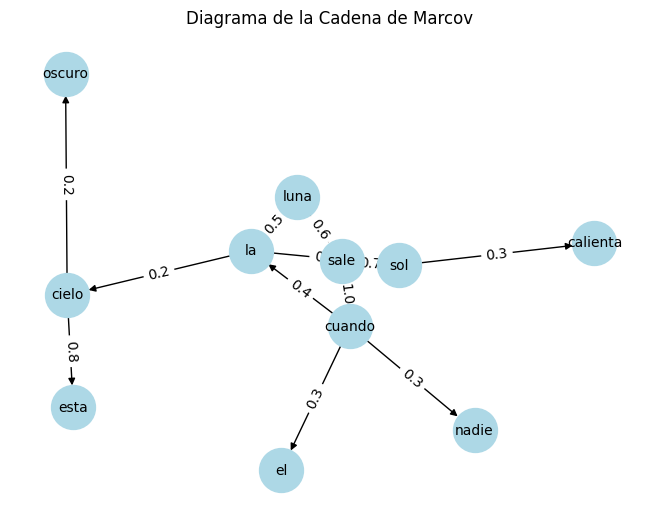

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

#Definimos una matriz de transicion para la cadena de Marcov
matriz_transicion = {
    'la': {'luna': 0.5, 'sol': 0.3, 'cielo': 0.2},
    'luna': {'sale': 0.6},
    'sale':{'cuando':1.0},
    'sol': {'sale': 0.7, 'calienta':0.3},
    'cielo': {'esta': 0.8,'oscuro':0.2},
    'cuando':{'la':0.4,'el':0.3,'nadie':0.3}
    }

#Crear un objeto de grafico dirigido
G = nx.DiGraph()

#agregar nodos al grafico (estados)
for estado in matriz_transicion:
  G.add_node(estado)

#agregar arcos ponderados al grafico (transiciones)
for estado, transiciones in matriz_transicion.items():
  for siguiente_estado, probabilidad in transiciones.items():
    G.add_edge(estado, siguiente_estado, weight=probabilidad)

#dibujar el trafico
pos = nx.spring_layout(G, seed=42) #colocacion de nodos
labels = nx.get_edge_attributes(G, 'weight')

nx.draw(G, pos, with_labels = True, node_size = 1000, node_color ='lightblue', font_size = 10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('Diagrama de la Cadena de Marcov')
plt.show()

# 1. Modelo del clima usando numpy

Aquí ya trabajamos con matrices de transición, que es la forma formal de las cadenas de Markov.

# Desde cero  

In [21]:
import random

# Definición manual del modelo
transiciones = {
    "Soleado":[("Soleado",0.8),("Nublado",0.15),("Lluvioso",0.05)],
    "Nublado":[("Soleado",0.2),("Nublado",0.5),("Lluvioso",0.3)],
    "Lluvioso":[("Soleado",0.2),("Nublado",0.2),("Lluvioso",0.6)]
}

def siguiente_estado(estado_actual):
  opciones=transiciones[estado_actual]
  r = random.random() #número entre 0 y 1
  acumulado = 0
  for estado, prob in opciones:
    acumulado += prob
    if r <= acumulado:
      return estado

def simular_clima(estado_inicial, dias):
  estado = estado_inicial
  historial = [estado]

  for _ in range(dias):
    estado = siguiente_estado(estado)
    historial.append(estado)

  return historial

In [24]:
#Ejemplo
resultado = simular_clima ("Soleado",10)
print("simulación del clima:")
print(resultado)

simulación del clima:
['Soleado', 'Soleado', 'Soleado', 'Soleado', 'Nublado', 'Nublado', 'Lluvioso', 'Lluvioso', 'Lluvioso', 'Lluvioso', 'Nublado']


<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>